# Goal 2：单项候选、反例与阶段案例

C-S、C-D、C-P 分别只改变一个参数组，保留开发选择和 G2_EVAL 确认的区别。没有独立真值的自然数据只支持条件化覆盖、几何与约束结论。构造反例具有明确解析答案，其误删/漏检计数不能外推到真实数据。

In [1]:
from pathlib import Path
import sys, json, tempfile, shutil
from html import escape
from IPython.display import display, Image, HTML
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'AGENTS.md').is_file() and (p/'task1').is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from task1.workflow.io import read_json, digest, object_hash
from task1.workflow.g2_provider import ExperimentProvider
model_sentinel = {'calls': 0}
def reject_model_call(*args, **kwargs):
    model_sentinel['calls'] += 1
    raise RuntimeError('RECOMPUTE_FORBIDS_NEW_MODEL_CALLS')
ExperimentProvider.call = reject_model_call
EV = ROOT/'task1/evidence/goal2'
current = read_json(EV/'current_runs.json')
contract = read_json(ROOT/'task1/config/goal2/contract.json')
split = read_json(EV/'data/split_manifest.json')
MODE = 'RECOMPUTE'
ENABLE_LIVE = False
assert MODE == 'RECOMPUTE' and ENABLE_LIVE is False, '新的 LIVE 调用须使用独立命令并显式启用，默认 Notebook 不发起模型请求。'
WORK = Path(tempfile.mkdtemp(prefix='sc-g2-notebook-'))
def show(rows):
    rows = list(rows)
    columns = list(dict.fromkeys(key for row in rows for key in row))
    header = ''.join('<th>'+escape(str(key))+'</th>' for key in columns)
    body = ''.join('<tr>'+''.join('<td>'+escape(str(row.get(key, '')))+'</td>' for key in columns)+'</tr>' for row in rows)
    display(HTML('<table><thead><tr>'+header+'</tr></thead><tbody>'+body+'</tbody></table>'))
def figure(name):
    directory = Path(recomputed.get('figure_directory', WORK/'figures'))
    target = directory/(name+'.png')
    assert target.is_file(), f'复算图缺失: {target}'
    display(Image(filename=str(target), width=1050))
print('运行方式:', MODE, '| 新模型调用:', 0)
print('原始来源 datum:', contract['source_crs'], '| 单位: 工作米 / 原始相对秒')
print('当前固定分区:', {name:len(ids) for name,ids in split['splits'].items()})


运行方式: RECOMPUTE | 新模型调用: 0
原始来源 datum: UNVERIFIED | 单位: 工作米 / 原始相对秒
当前固定分区: {'PILOT_REGRESSION': 7, 'DEMO_MEMORY': 60, 'DEVELOPMENT': 120, 'G2_EVAL': 120, 'G3_RESERVED': 11079}


## 从 raw 复算候选确认与反例

固定候选后才打开 G2_EVAL。本段重新执行对应真实数据处理与构造反例，检查保存结果一致；它是复现，不产生新的选择机会或独立实验数量。

In [2]:
from task1.scripts.goal2 import recompute
recomputed = recompute(topic='candidates', output_directory=WORK, rebuild_figures=True)
assert recomputed['status'] == 'VERIFIED', recomputed
assert recomputed['new_model_calls'] == 0, recomputed
assert model_sentinel['calls'] == 0, model_sentinel
print('从 raw 和冻结提议复算:', recomputed['status'])
print('新增模型调用:', recomputed['new_model_calls'])
print('检查项数量:', len(recomputed['checks']))
show(recomputed['checks'][:20])
print('全部检查结果保存在独立复算输出，不把重复计算计为新独立实验。')


{'status': 'ENGINEERING_VERIFIED', 'synthetic_pipeline_executions': 19, 'pilot_pipeline_executions': 10, 'known_answer_checks': 25, 'experiment_model_dispatches': 0, 'elapsed_seconds': 1.4904665289977856}


{"figures": 11, "raster_check": "PASSED", "visual_inspection": "PENDING_ACTUAL_IMAGE_REVIEW"}
从 raw 和冻结提议复算: VERIFIED
新增模型调用: 0
检查项数量: 1


全部检查结果保存在独立复算输出，不把重复计算计为新独立实验。


In [3]:
lock = read_json(EV/'candidate_lock.json')
assert lock['source_partition']=='DEVELOPMENT' and lock['g2_eval_observed_for_selection'] is False
show([{'candidate':name,**row} for name,row in lock['selected_single_candidates'].items()])
print('额外结构候选:',lock['structural_candidates'])
print('仅以下冻结顺序进入阶段留出:',lock['feasible_orders'])

candidate,config_id,parameters,selection_reason,eligible_gain_ids,pareto_frontier,domain_ids,research_status,final_method_frozen
C-S,cfg-1e535c3fe3cc8ae1,"{'dt': 30, 'distance': 400, 'min_points': 2, 'min_length': 0, 'direction': 35, 'dp': 5}",UNIQUE_PROTECTED_PARETO_GAIN,"['cfg-6599edd5fcbf75b1', 'cfg-d4df6d869dc800d6', 'cfg-63139d05595c253c', 'cfg-5279f18a16a391af', 'cfg-1e535c3fe3cc8ae1', 'cfg-81a89e633001f457', 'cfg-a676557c7da6251e', 'cfg-901645379df0db06']",['cfg-1e535c3fe3cc8ae1'],"['cfg-5f3726776663985b', 'cfg-7b4506482fa0b5f2', 'cfg-b15b8281b73592fb', 'cfg-85746847a32cb544', 'cfg-d4ff6528d1731c17', 'cfg-0ad662cd1af68eaf', 'cfg-c75c27c441321c6a', 'cfg-cfcdb0f0e22b991f', 'cfg-7261bd230cb316ee', 'cfg-6599edd5fcbf75b1', 'cfg-d4df6d869dc800d6', 'cfg-38b5af70752afcf3', 'cfg-7a5c632edc26a683', 'cfg-63139d05595c253c', 'cfg-5279f18a16a391af', 'cfg-2145210f6818db22', 'cfg-dc3bdca5d6cb9c1f', 'cfg-672c311f4dabd45c', 'cfg-a14223bb071ea6fe', 'cfg-fd21019cc8ca3842', 'cfg-3f2e270c7b010996', 'cfg-522fba6abbf5d1bc', 'cfg-9733e27113ed91ea', 'cfg-857da90ed04ebbbe', 'cfg-43be70fbb61e9927', 'cfg-a44fa1691cdad5d4', 'cfg-90310668f6147653', 'cfg-7380d059299db45a', 'cfg-4ba6fa8d8c11a024', 'cfg-56d9babc85c51d64', 'cfg-b3034e58a529fd4a', 'cfg-060195700887c44a', 'cfg-628483ab24c0b6b1', 'cfg-1e535c3fe3cc8ae1', 'cfg-81a89e633001f457', 'cfg-3096d8e282282635', 'cfg-7b664c0314ac01a9', 'cfg-a676557c7da6251e', 'cfg-901645379df0db06', 'cfg-4ad6ba13aaf512f3', 'cfg-b985b9509ecc8ff6', 'cfg-7de891c7d65fc173', 'cfg-9d355d795468065c', 'cfg-69a9139380a0edd9', 'cfg-15934b797839150f', 'cfg-64af02f0e5043228', 'cfg-00ad40b806af82f6', 'cfg-76a4880c98ee54c6', 'cfg-c19c8952dfd15e20']",SUPPORTED_WITHIN_SCOPE,False
C-D,cfg-b15b8281b73592fb,"{'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 5}",NO_UNIQUE_COMPARABLE_GAIN_KEEP_REFERENCE,[],[],"['cfg-b15b8281b73592fb', 'cfg-6b37e535e1ea2046', 'cfg-893931df60c3d3d6', 'cfg-24646b7acfafee8e', 'cfg-a5483ca9cb883a91']",NO_DEMONSTRATED_GAIN,False
C-P,cfg-b15b8281b73592fb,"{'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 5}",NO_UNIQUE_COMPARABLE_GAIN_KEEP_REFERENCE,[],[],"['cfg-b15b8281b73592fb', 'cfg-b64eb945a846910c', 'cfg-59d5d0c23b67d172', 'cfg-322e68540606f046', 'cfg-df6f00206fb03678', 'cfg-65d9f66c5a9b483a', 'cfg-e8ff0df5800d5c3b']",NO_DEMONSTRATED_GAIN,False


额外结构候选: [{'id': 'C-STRATIFIED', 'status': 'NOT_ADMITTED_WITH_REASON', 'reason': 'No independently justified conditional parameter policy beyond the required controlled parameter experiments; optional scope not filled by invented motion labels.'}, {'id': 'C-DIRECTION-GUARD', 'status': 'NOT_ADMITTED_WITH_REASON', 'reason': 'No independently justified displacement reliability threshold frozen; no arbitrary low-displacement cutoff introduced.'}]
仅以下冻结顺序进入阶段留出: ['S-D-P', 'S-P-D']


## G2_EVAL：三个冻结单项的确认结果

下面读取已经由独立 C 核验的确认表，并把它绑定到上面刚从 raw 复算的同一 run、候选、记录范围与文件哈希。表中保护通过和严格改善以原始记录为单位；共同覆盖以原始点为分母。C-D、C-P 若保留 reference，会共享同一次计算，不新增独立证据。`SUPPORTED_WITHIN_SCOPE` 只表示冻结保护下的条件化几何/覆盖支持，不等于真实清洗准确率或最终采用。完整分层、失败与结论边界见[阶段技术分析](../../docs/goal2/STAGE_ANALYSIS.md)。

In [4]:
confirmation_path = EV/'a_epoch02/heldout_single_confirmation/single_candidate_confirmation.json'
confirmation = read_json(confirmation_path)
confirmation_review = read_json(EV/'c_contract/single_candidate_confirmation_receipt.json')
assert confirmation_review['status'] == 'VERIFIED' and not confirmation_review['errors']
targets = {item['path']:item['sha256'] for item in confirmation_review['targets']}
assert targets[str(confirmation_path.relative_to(ROOT))] == digest(confirmation_path)
for path, expected in targets.items():
    assert digest(ROOT/path) == expected, path
for name in ('candidate_lock', 'evaluation_freeze'):
    binding = confirmation[name]
    assert digest(ROOT/binding['path']) == binding['sha256']
assert confirmation['input_scope']['partition'] == 'G2_EVAL'
assert confirmation['input_scope']['record_ids'] == split['splits']['G2_EVAL']
eval_run_id = current['evaluation_parameters']
eval_manifest_path = EV/'runs'/eval_run_id/'manifest.json'
assert digest(eval_manifest_path) == confirmation['input_hashes'][str(eval_manifest_path.relative_to(ROOT))]
eval_manifest = read_json(eval_manifest_path)
raw_check = next(item for item in recomputed['checks'] if item.get('run_id') == eval_run_id)
assert raw_check['status'] == 'VERIFIED'
recomputed_keys = {item['experiment_key'] for item in raw_check['checks'] if item['exact_output_match'] and item['review_status'] == 'VERIFIED'}
independent = {row['candidate']:row for row in confirmation_review['independent_results']}
heldout_rows = []
for row in confirmation['candidate_results']:
    selected = lock['selected_single_candidates'][row['candidate']]
    assert row['config_id'] == selected['config_id']
    assert {key:row[key] for key in selected['parameters']} == selected['parameters']
    calculation = row['computation']
    assert calculation['run_id'] == eval_run_id and calculation['experiment_key'] in recomputed_keys
    entry = eval_manifest['artifacts'][calculation['experiment_key']]
    assert entry['config_id'] == row['config_id']
    for key in ('n_records', 'n_input', 'n_final', 'common_raw_points', 'common_covered_points', 'n_no_output_records'):
        assert row[key] == entry['summary'][key], (row['candidate'], key)
    assert row['strict_gain_records'] == independent[row['candidate']]['strict_gain_records']
    assert row['feasible_records'] == independent[row['candidate']]['protected_records']
    assert row['evaluation_status'] == independent[row['candidate']]['independent_status']
    heldout_rows.append({'candidate':row['candidate'], 'config_id':row['config_id'],
        'protected_records':f"{row['feasible_records']}/{row['n_records']}",
        'strict_gain_records':f"{row['strict_gain_records']}/{row['n_records']}",
        'covered_raw_points':f"{row['common_covered_points']}/{row['common_raw_points']}",
        'retained_raw_points':f"{row['n_final']}/{row['n_input']}",
        'no_output_records':f"{row['n_no_output_records']}/{row['n_records']}",
        'research_status':row['evaluation_status'], 'quality_accepted':row['quality_accepted']})
assert {row['candidate'] for row in heldout_rows} == {'C-S', 'C-D', 'C-P'}
baseline = confirmation['reference_summary']
print('共同 reference: 覆盖', baseline['common_covered_points'], '/', baseline['common_raw_points'],
      '原始点；无输出', baseline['n_no_output_records'], '/', baseline['n_records'], '记录')
show(heldout_rows)
print('已完成 raw 复算并复用同一证据；新增选择、新模型调用、新独立实验均为 0。')


共同 reference: 覆盖 8805 / 12173 原始点；无输出 32 / 120 记录


candidate,config_id,protected_records,strict_gain_records,covered_raw_points,retained_raw_points,no_output_records,research_status,quality_accepted
C-S,cfg-1e535c3fe3cc8ae1,120/120,53/120,12162/12173,2939/12173,0/120,SUPPORTED_WITHIN_SCOPE,False
C-D,cfg-b15b8281b73592fb,120/120,0/120,8805/12173,2748/12173,32/120,NO_DEMONSTRATED_GAIN,False
C-P,cfg-b15b8281b73592fb,120/120,0/120,8805/12173,2748/12173,32/120,NO_DEMONSTRATED_GAIN,False


已完成 raw 复算并复用同一证据；新增选择、新模型调用、新独立实验均为 0。


## 解析构造反例

正常转弯、合法 zigzag 和注入毛刺说明方向几何不是噪声真值。零位移和零时间差保留不可计算原因。有限线段反例拒绝无限直线捷径；P 先删触发点可能掩盖原始断点。整条无输出无法凭缺少异常获得好分，各自 clean 的零 DP 误差不能证明跨方法整体更好。这里检验风险，不伪造实际模型错误或用户质疑。

case,family,checks,passed,interpretation
CE01_DIRECTION_AMBIGUITY,normal sharp turn versus spike,3,True,"A single right-angle turn is retained here, but legitimate zigzag vertices satisfy the same deletion predicate. In the authored spike example the method deletes one normal neighbor together with the injected spike. Geometry alone is not a noise truth label."
CE02_UNDEFINED_IS_NOT_ZERO,zero displacement and same time different position,4,True,"Zero displacement has undefined direction; zero dt has undefined speed, including the moving same-time edge. These are explicit reasons, not fabricated zero velocities or a physical speed limit."
CE03_ORDER_AND_BREAK_INFORMATION,time/distance break and P removes trigger,5,True,P preserves its own geometric tolerance but can remove breakpoint trigger information. On the time fixture later S filters the two remaining singleton segments; on the distance fixture a 399-metre final edge crosses the original 401-metre break.
CE04_FINITE_DISTANCE_AND_EQUALITY,finite segment versus infinite line and threshold equality,6,True,"The middle point projects beyond the finite endpoint, so its finite distance is sqrt(2), not the infinite-line distance 1. A separate exact-height example verifies strict recursion and dp=0 identity."
CE05_EMPTY_OUTPUT_IS_NOT_SUCCESS,delete-all scoring loophole,4,True,"An empty output contains no observed anomaly but also no covered raw points. Error and DP saving are unavailable, not perfect zeros; complete input membership remains visible."
CE06_OWN_CLEAN_IS_NOT_COMMON_TRUTH,different clean references cannot certify overall improvement,3,True,Both P stages copy their own inputs exactly and report error zero; the direction=35 path has already removed a point. Its common raw-reference error is positive while direction=60 remains zero. Separate DP certificates therefore cannot establish cross-method quality.


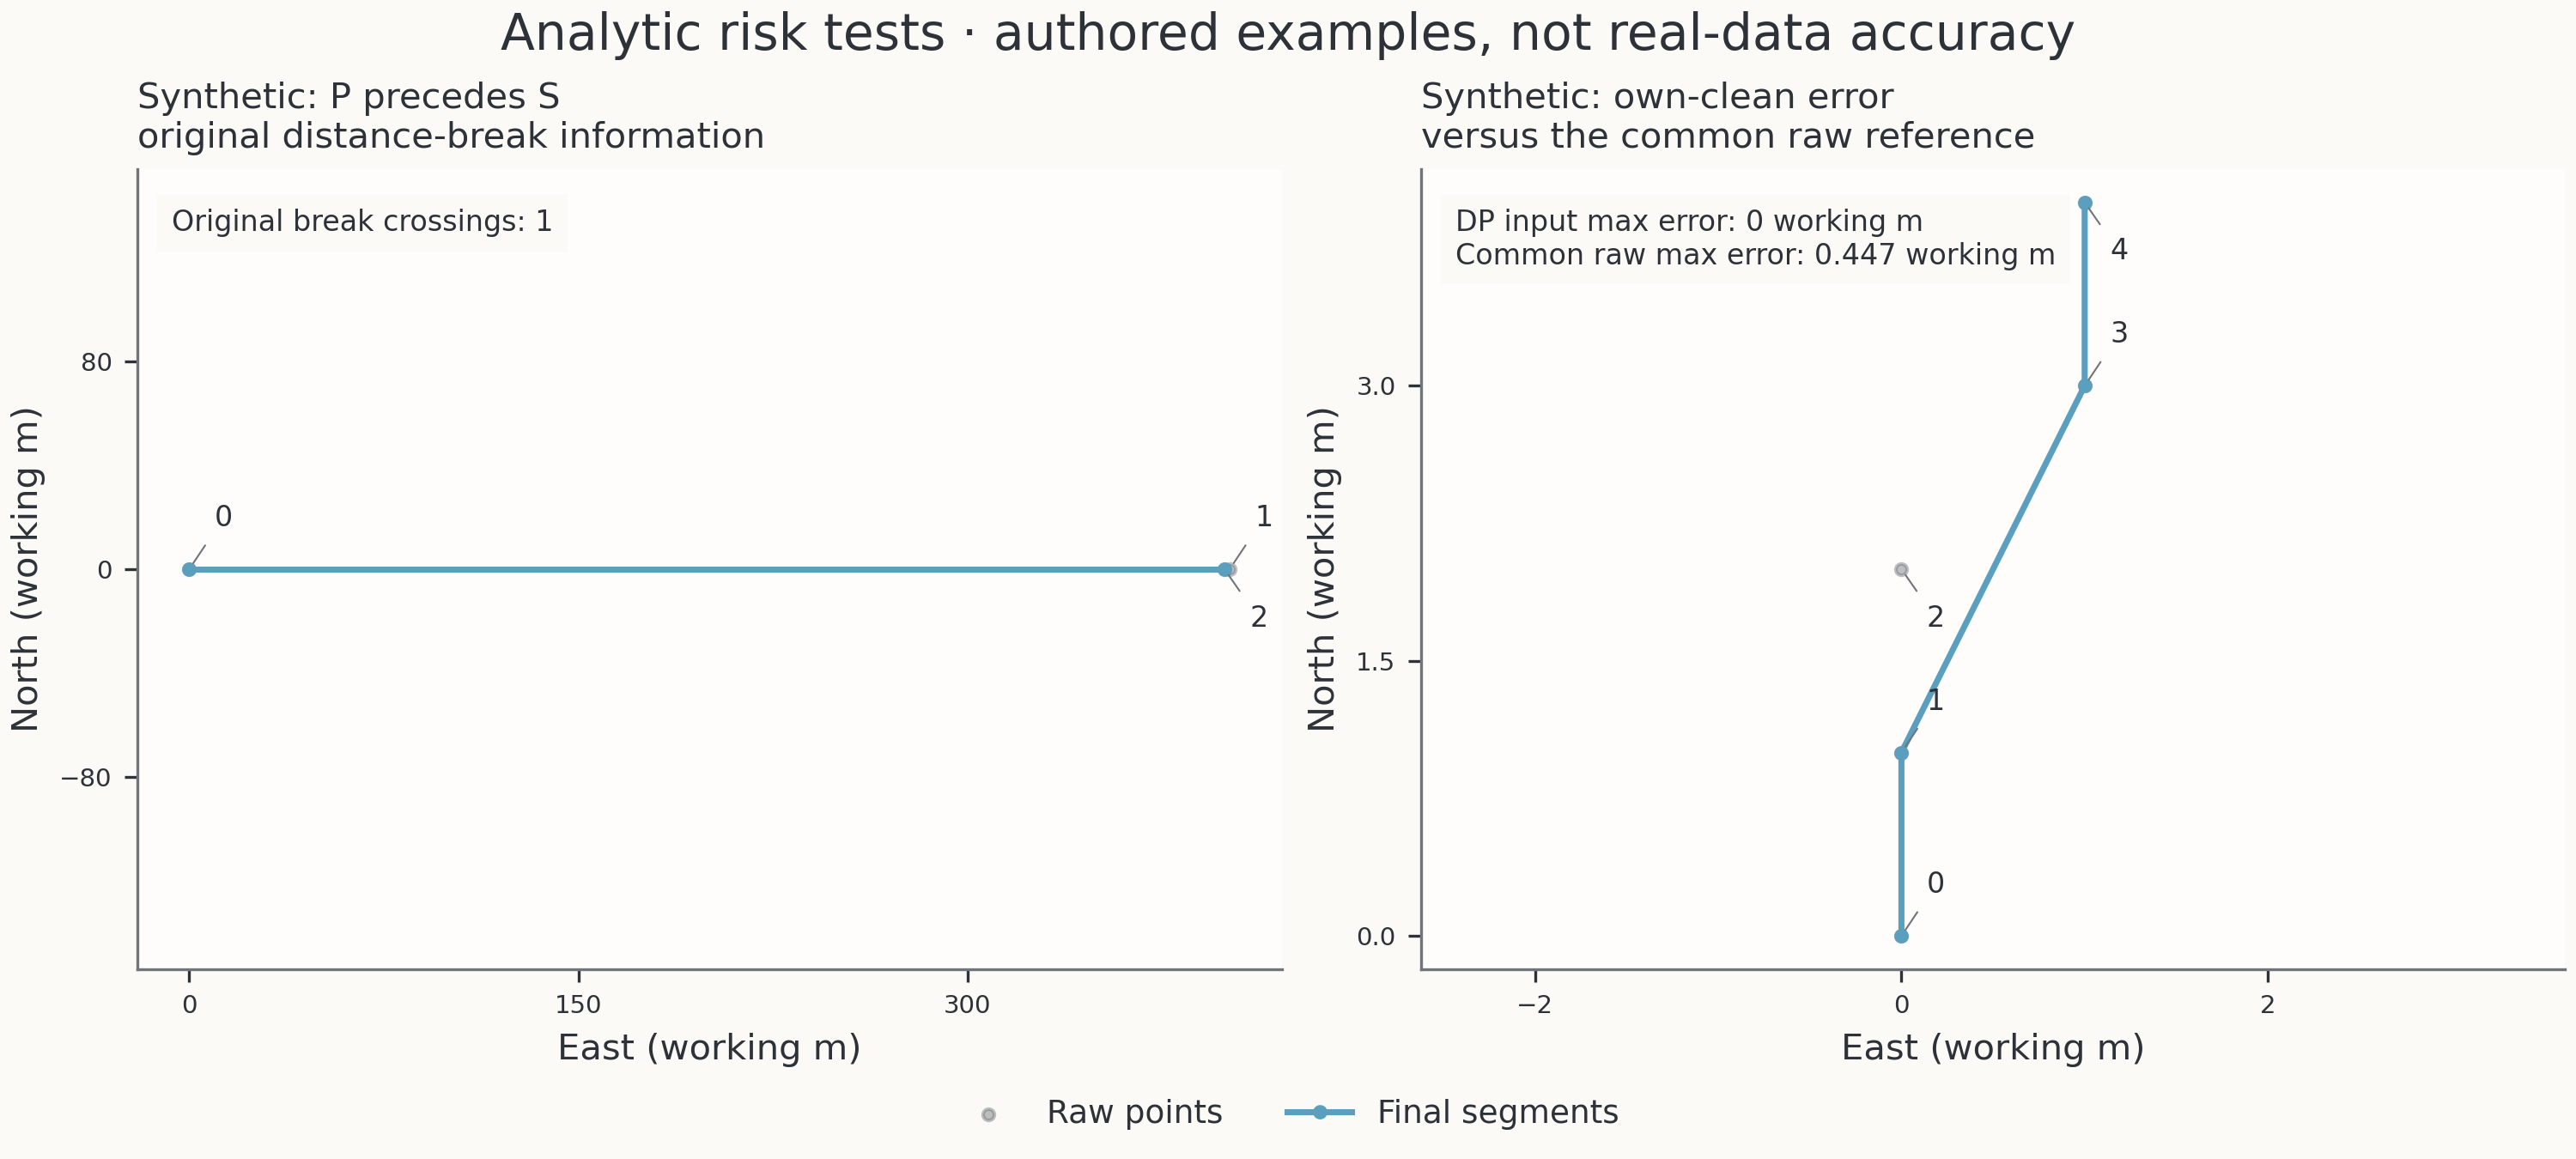

In [5]:
counter_directory = ROOT/current['counterexamples']
synthetic = read_json(counter_directory/'synthetic_cases.json')
assert synthetic['classification']=='SYNTHETIC_COUNTEREXAMPLE'
show([{'case':case['case_id'],'family':case['family'],'checks':len(case['known_answer_checks']),'passed':all(check['passed'] for check in case['known_answer_checks']),'interpretation':case['interpretation']} for case in synthetic['cases']])
figure('synthetic_metric_counterexamples')

## 真实案例：代表样本、退化与近阈值

出图前按原始跨度层中位代表、最大覆盖损失、最大共同误差、最小正 P 阈值间隔规则登记案例。图只在工作平面显示点和真实输出片段，不叠加未核实底图，不跨记录/分段连线。缺输出同样保留。

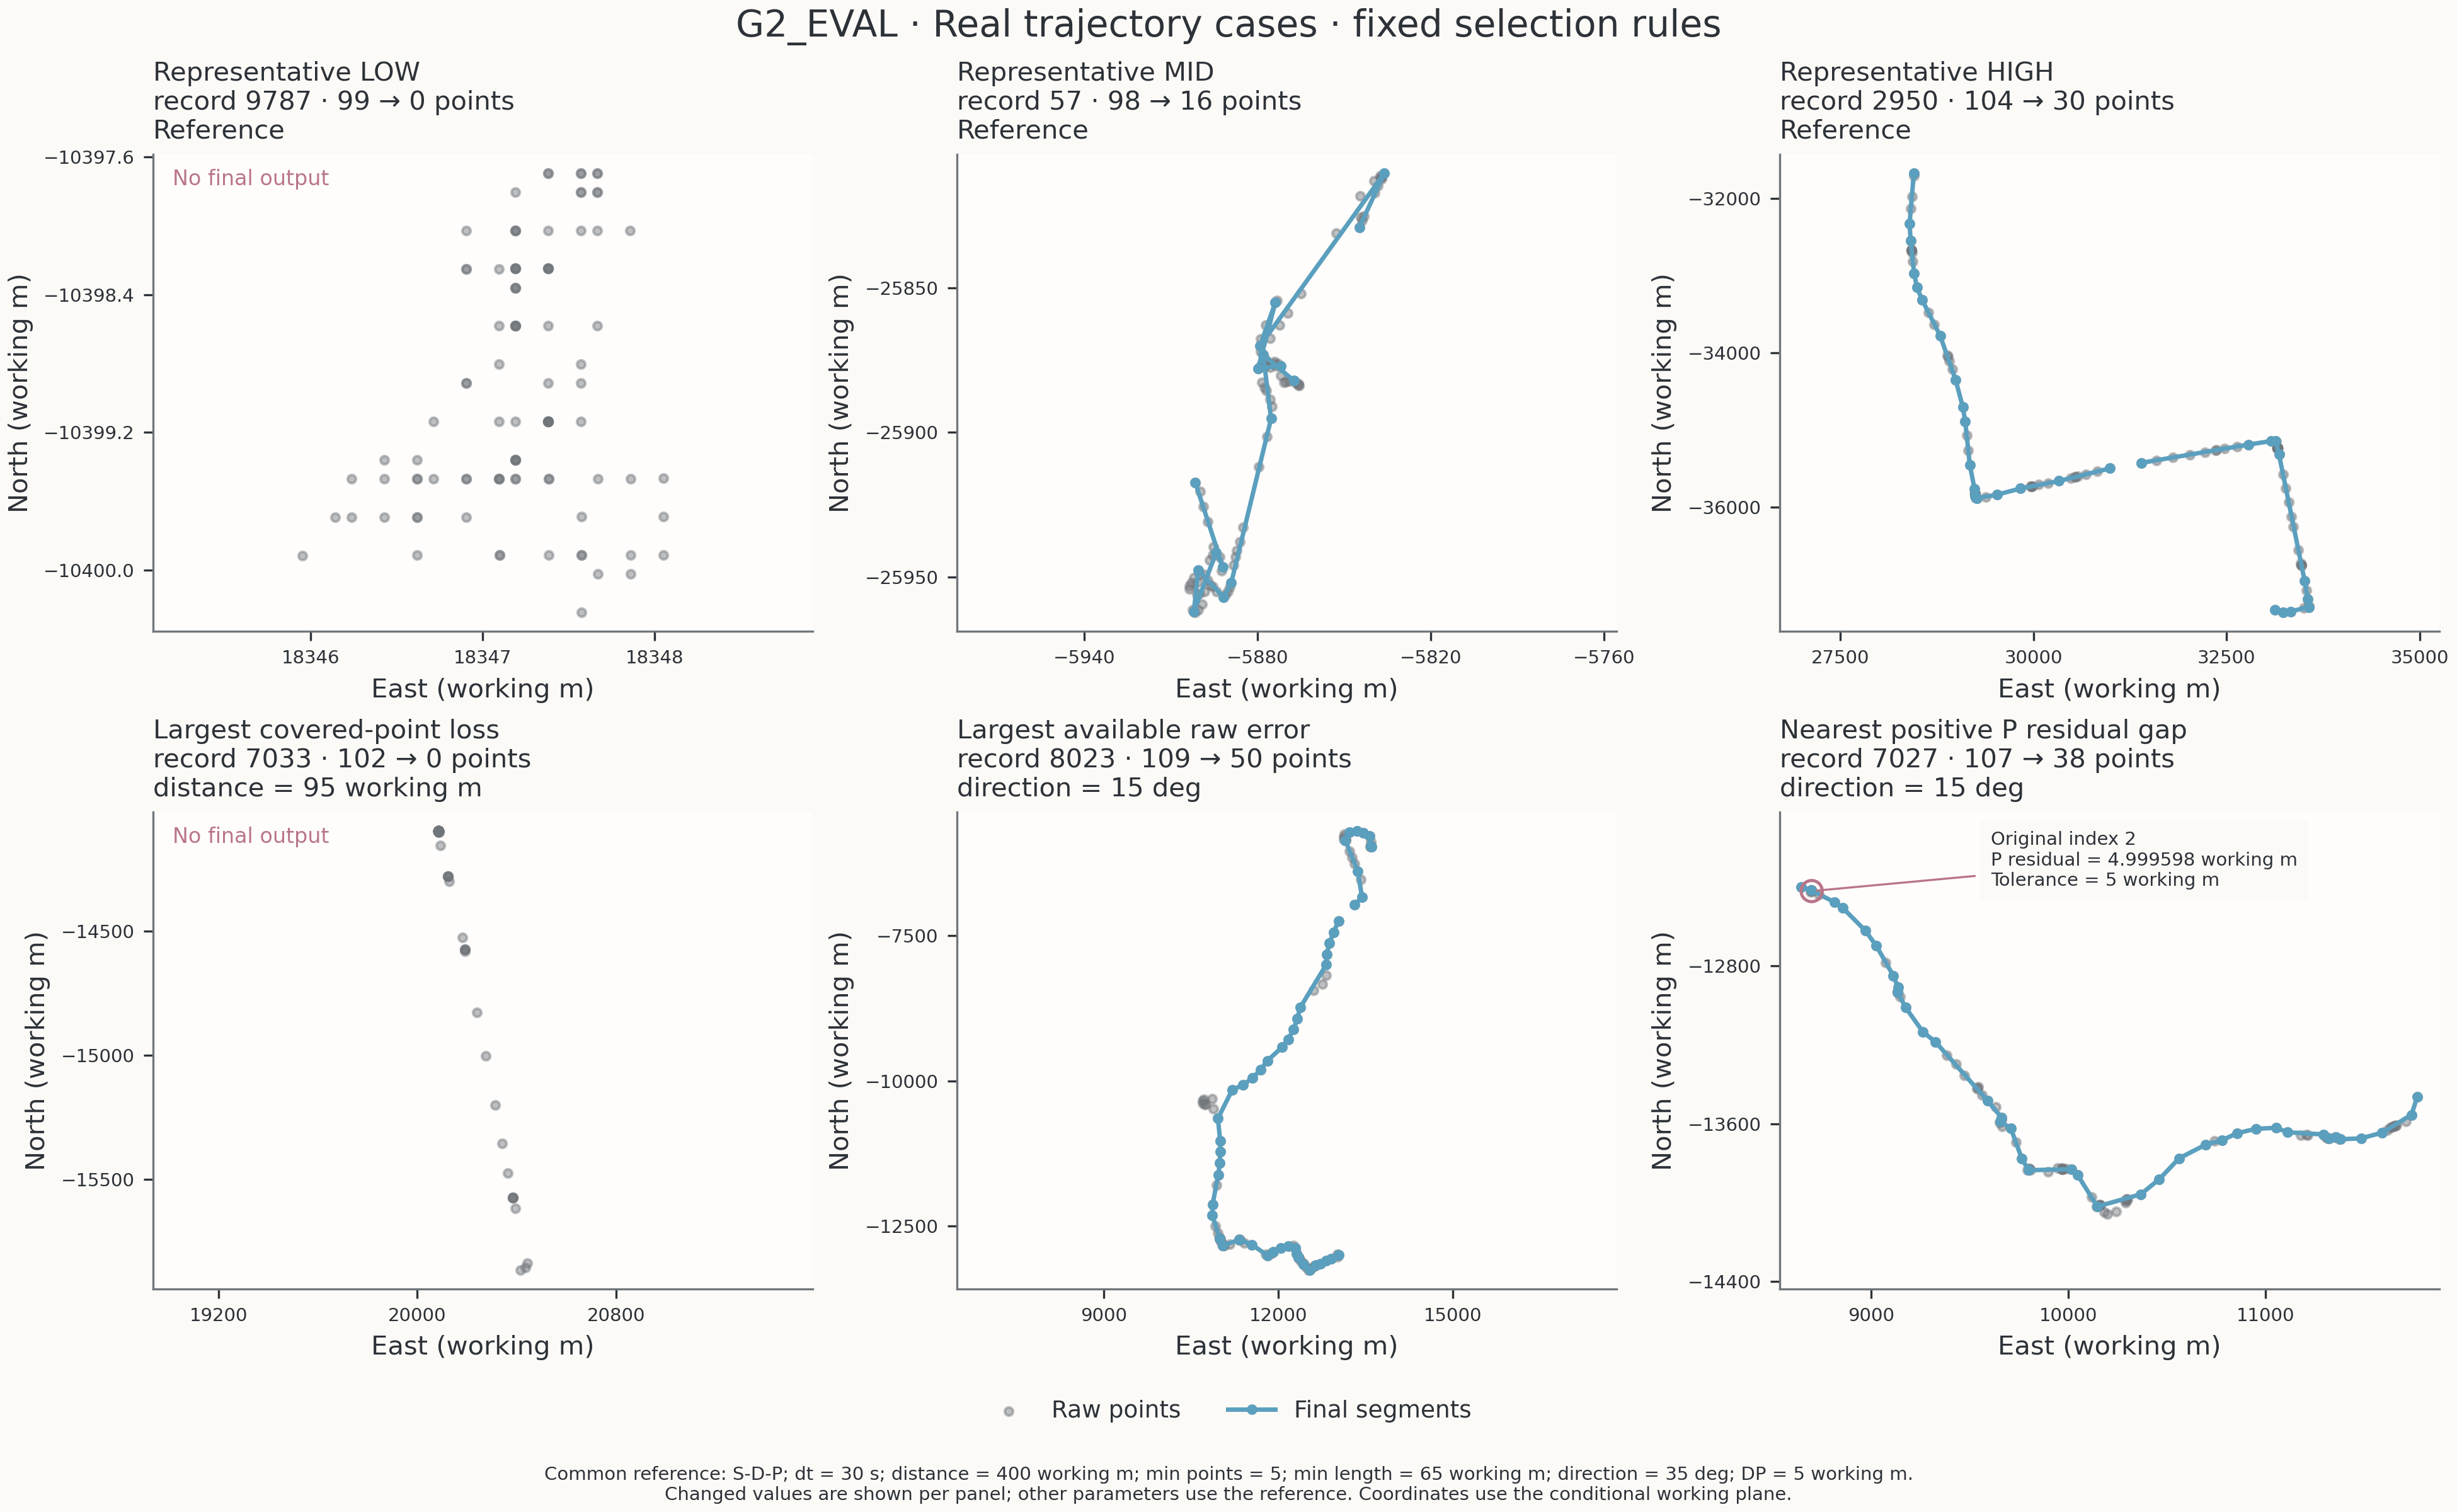

record_id,raw_points,final_points,segments
0,99,0,"[{'n': 99, 'length_working_m': 12.281263484296785, 'reasons': ['TOO_SHORT_LENGTH']}]"
1,97,0,"[{'n': 97, 'length_working_m': 23.53944610383605, 'reasons': ['TOO_SHORT_LENGTH']}]"
2,99,0,"[{'n': 99, 'length_working_m': 4.171537495124748, 'reasons': ['TOO_SHORT_LENGTH']}]"


已暴露pilot近阈值: {'record_id': '306', 'original_index': 2, 'reference_bracketing_indices': [0, 12], 'actual_error_working_m': 4.938319812632411}


dp,n_dp_input,n_dp_output,dp_saving,dp_max_error,common_max_error
2,105,82,0.21904761904761905,1.8619448497736368,64.3600673932958
5,105,69,0.34285714285714286,4.938319812632411,64.3600673932958
10,105,57,0.4571428571428572,9.74737470889963,64.3600673932958


In [6]:
figure('real_trajectory_cases')
pilot = read_json(counter_directory/'exposed_pilot_cases.json')
show([{'record_id':row['record_id'],'raw_points':row['raw_points'],'final_points':row['final_points'],'segments':[{'n':part['n_points'],'length_working_m':part['within_segment_length_working_m'],'reasons':part['filter_reasons']} for part in row['segments']]} for row in pilot['all_filtered_records_0_1_2']])
near=pilot['near_threshold_case']
print('已暴露pilot近阈值:',{key:near[key] for key in ('record_id','original_index','reference_bracketing_indices','actual_error_working_m')})
show([{'dp':threshold,**row} for threshold,row in near['before_after'].items()])

## 实际生产工作流与被评估系统

主线程负责父 Goal；A 安排冻结范围内实验，B 执行或修复，独立 C 从可信原始输入核验。确定性 GoalJournal 检查版本、依赖和回执。普通问题经过修复、复验、失效产物重建后恢复父任务；这些角色调用与四模式内部调用分开计数。

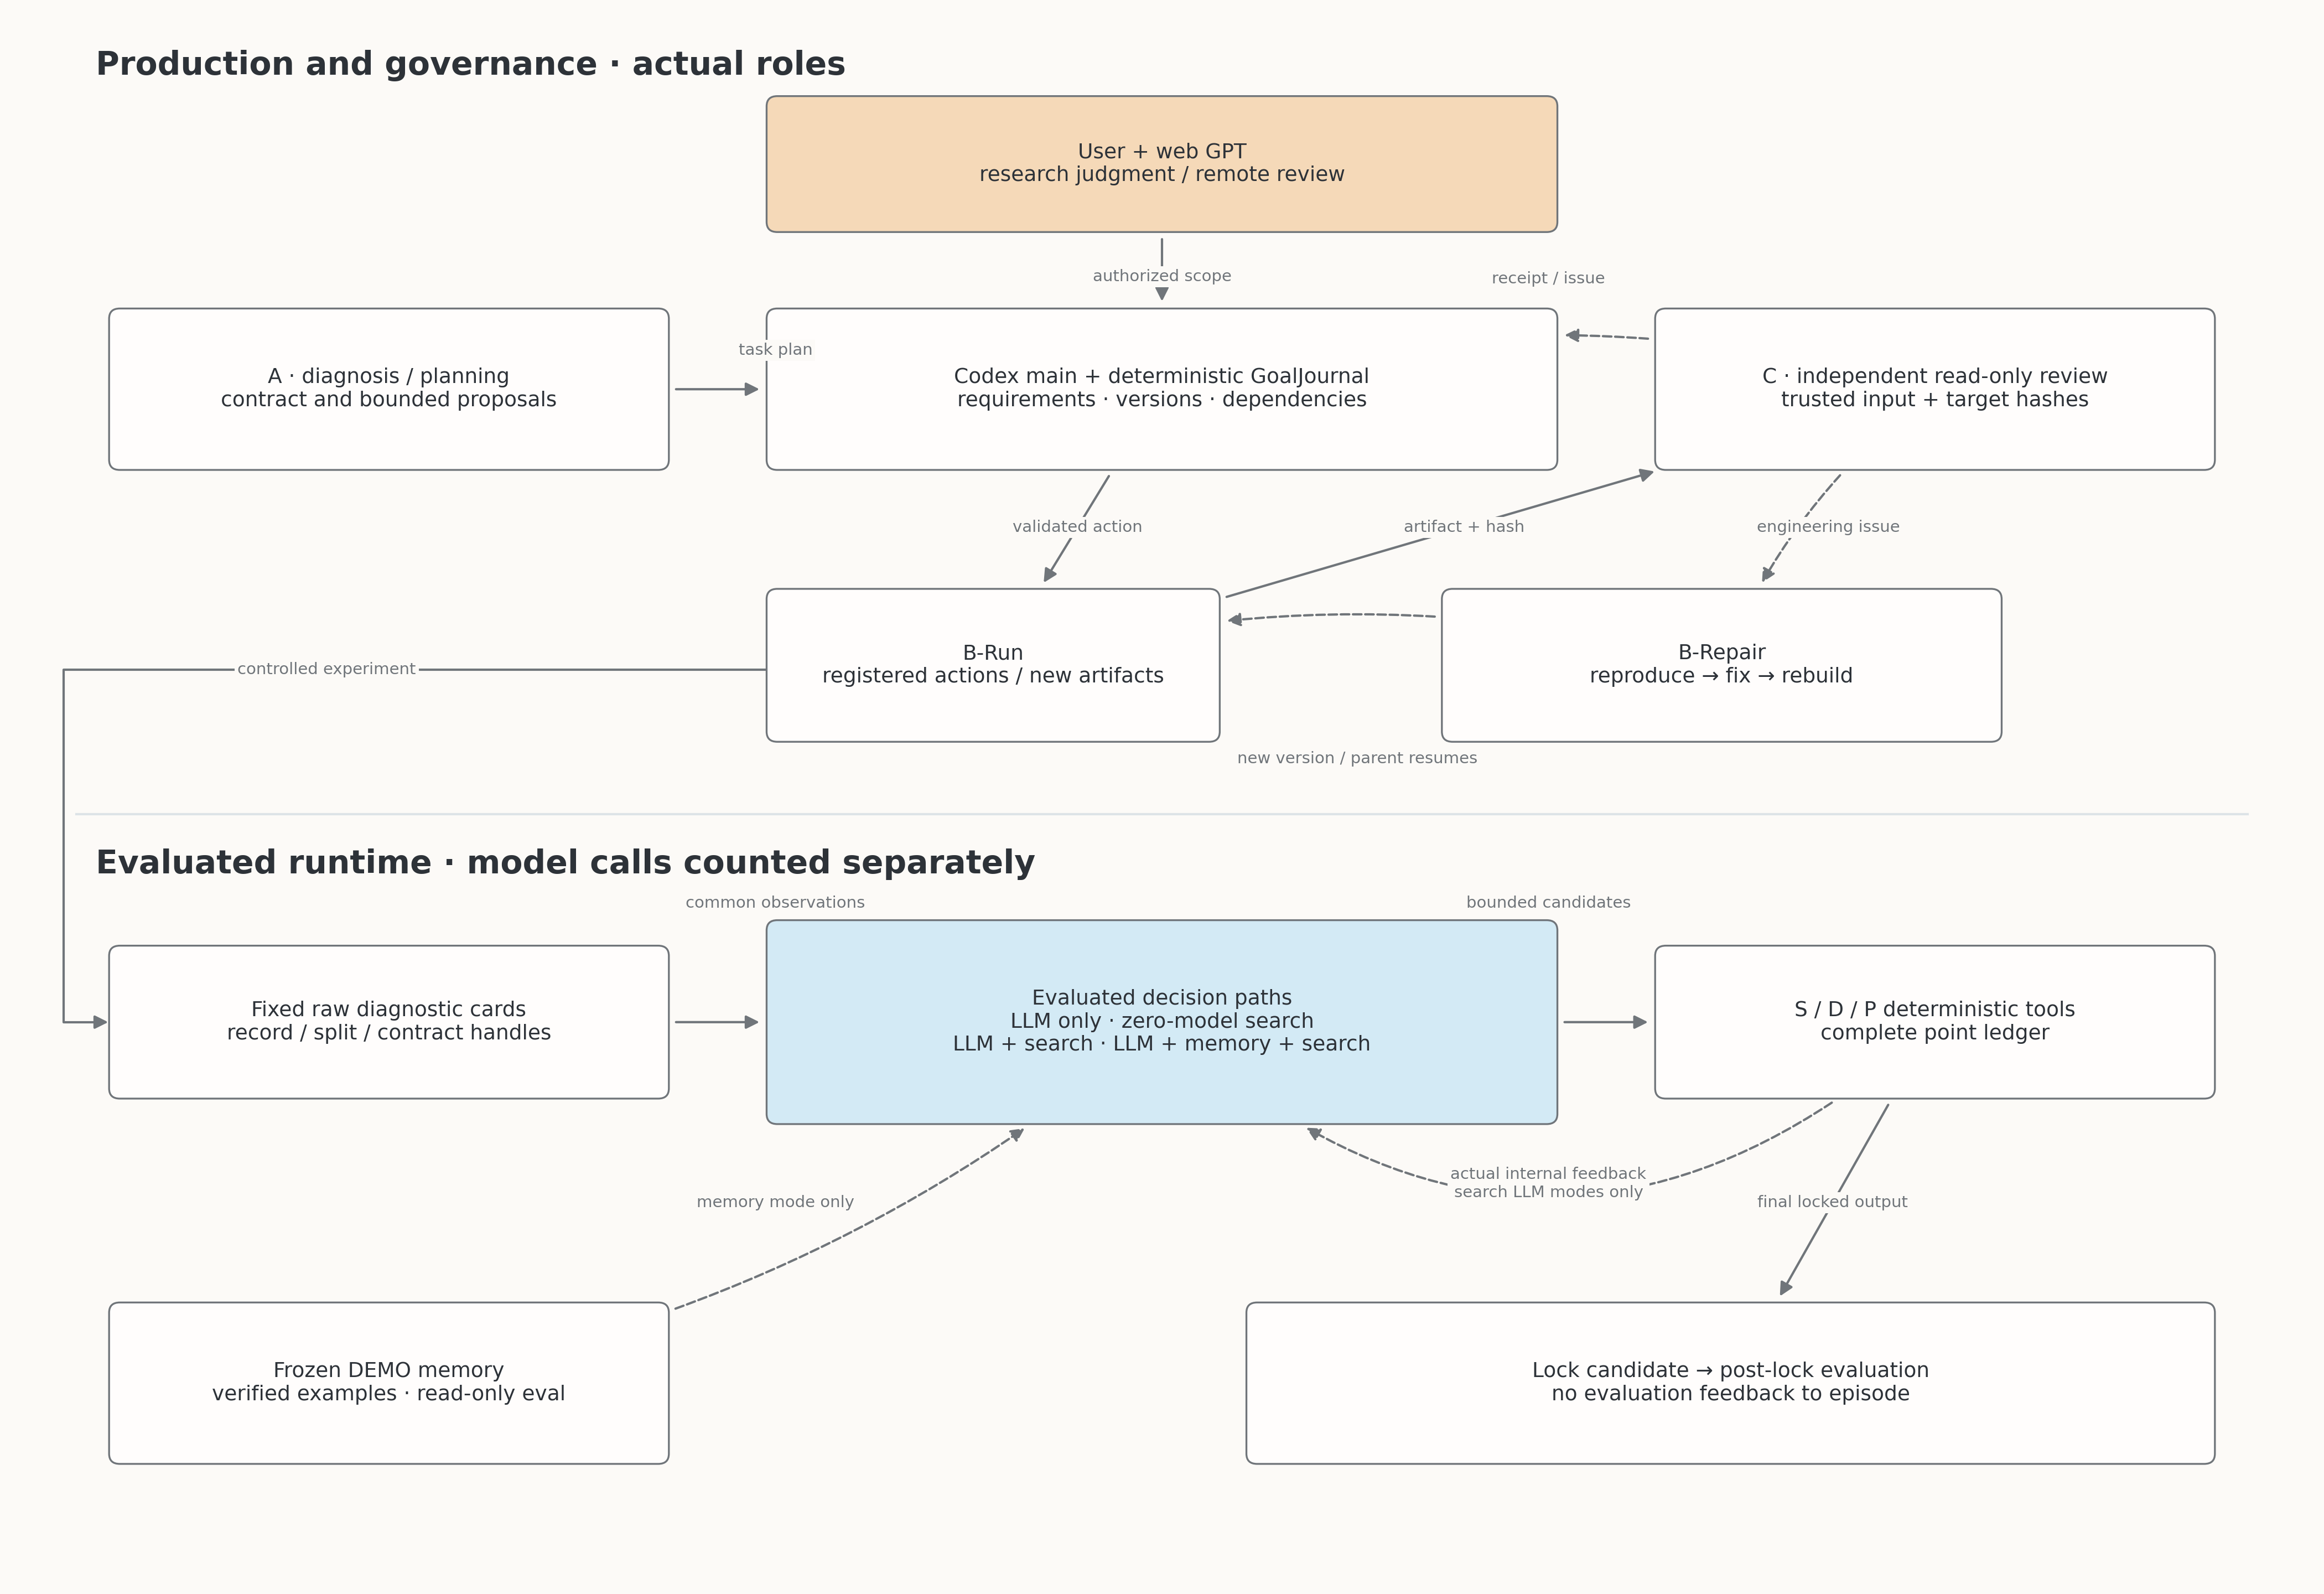

issue,parent_task,status,fact,repairer,verifier
G2-C-CONTROL-001,core,VERIFIED,"Initial G2Journal.accept accepts empty target sets, unrelated check coverage, unsatisfied task prerequisites and a wrong source-hash claim.",B-Repair:root,C:/root/c_contract
G2-C-MODE-MEMORY-001,core,VERIFIED,Static independent review found schema-invalid answers could be retried and public in-process memory snapshot could be mutated.,B-Repair:root,C:/root/c_contract
G2-C-SOURCE-SCOPE-001,core,VERIFIED,"Follow-up static review found resume partition/source-set, candidate manifest summary and cache review binding gaps before formal runs.",B-Repair:root,C:/root/c_contract
G2-B-NOTEBOOK-001,notebooks,VERIFIED,Notebook SETUP imported pandas but existing .venv has no pandas distribution; text claimed a Provider sentinel although none was installed.,B-Repair:/root,C:/root/c_contract
G2-B-FIGURE-001,figures,VERIFIED,Actual parameter figure preview showed non-data diagonal color bands in PDF heatmap rendering and direction neighborhood compressed into narrow axes/covered by legend. The first layout repair used unsupported Matplotlib 3.6.3 outside-legend location and raised an actual rendering exception.,B:/root/b_engine,C:/root/c_contract
G2-C-CONTEXT-001,development_modes,VERIFIED,Independent C found 13 mismatches between record round.context_hash and immutable saved round2/3 context; own_prior_proposal_validation shared mutable proposal list. Actual model input/response/numeric schedule remained matched in inspected batch.,B-Repair:/root,C:/root/c_contract
G2-B-RETRY-CLASSIFIER-001,core,VERIFIED,Intentional SIGINT produced receipt.error KeyboardInterrupt but dispatch falsely labeled EXTERNAL_AUTH_PERMISSION_OR_BILLING_BLOCKED by searching arbitrary hash fields for 401/403. No real authorization failure occurred.,B-Repair:/root,C:/root/c_contract
G2-C-RECEIPT-TARGET-001,evaluation_parameters,VERIFIED,Controller rejected parameter acceptance because B submitted execution/artifact-check receipts while C numeric receipt bound manifest/table/freeze only; same extra-target gap also exists for order task.,B-Repair:/root,C:/root/c_contract
G2-B-CANDIDATE-FIGURE-001,figures,VERIFIED,"Actual candidate preview showed equal-aspect flat traces collapsing axes, overlapping labels/ticks and an all-filtered legend hiding the no-output label. Architecture C node incorrectly linked the production deterministic verifier rather than independent C scripts.",B:/root/b_engine,C:/root/c_contract
G2-B-CASE-CONFIG-001,figures,VERIFIED,"Root actual PDF inspection found real_trajectory_cases panels from different frozen EVAL configurations do not display their parameter differences: three reference representatives, distance=95 coverage-loss case, direction=15 error and near-threshold cases. Manifest binds correct configs but the rendered figure alone is underspecified.",B:/root/b_engine,C:/root/c_contract


Notebook执行时journal状态: IMPLEMENTING


In [7]:
figure('goal2_actual_architecture')
state=read_json(EV/'goal_state.json')
show([{'issue':key,'parent_task':row['parent_task'],'status':row['status'],'fact':row.get('fact'),'repairer':row.get('repairer'),'verifier':row.get('verifier')} for key,row in state.get('issues',{}).items()])
print('Notebook执行时journal状态:',state['status'])

## 下一阶段边界

本轮只保留支持、否定、权衡或证据不足的单项结果供 Goal 3 判断。组合、冻结最终方法、最终全量处理、两份正式报告定稿、Evidence Lock 和提交包均不在本工作 Notebook 执行。最终网页 GPT 二重审核不能由内部自检替代。

In [8]:
print('原始数据不变:',digest(ROOT/contract['raw_path'])==contract['raw_sha256'])
print('本次新模型调用:',recomputed['new_model_calls'])
print('GPT_SECOND_REVIEW=PENDING; Submission=NOT_READY')
shutil.rmtree(WORK)

原始数据不变: True
本次新模型调用: 0
GPT_SECOND_REVIEW=PENDING; Submission=NOT_READY
